In [ ]:
# =============================================================================
# Antibiotic Resistance Prediction using Proximity, Frequency, and G-score
# =============================================================================
# 
# This notebook trains and evaluates Random Forest classifiers on mutation-level
# features (mutation frequency, 3D structural proximity to known resistance-conferring
# mutations, and g-scores) to predict antibiotic resistance in Mycobacterium tuberculosis.
# It includes baseline modeling,combined modeling and predictions for uncertain mutations (Category 3).

In [ ]:
## load dependencies
import pandas as pd
import numpy as np
import re
from evcouplings.compare import DistanceMap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score,roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay)
from scipy import stats
import os,json
from utils import *

## data preprocessing

In [ ]:
# ----------------------------
# STEP 1: Load and Inspect Dataset
# ----------------------------
# new_data: sanjana's data
final_df = pd.read_csv("../data/new_data/all_proteins_freq_proximity_gscore.csv")
print("Unique genes:", np.unique(final_df['gene']))
print("Data shape:", final_df.shape)
final_df['one_letter_mutation'] = final_df['one_letter_mutation'].str.replace("p.", "").str.strip()


In [ ]:
# STEP 2: Basic Preprocessing
# ----------------------------
# Separate Category 3 entries (uncertain mutations)
category_3_data = final_df[final_df['confidence'] == "3) Uncertain significance"]
print(category_3_data.shape)

# Retain only labeled data (non-Category 3) for supervised learning
label_data = final_df[final_df['confidence'] != "3) Uncertain significance"]

# Target conversion to binary
label_data['binary_confidence'] = label_data['confidence'].map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0
})

# Drop missing targets
label_data = label_data[label_data['binary_confidence'].notna()]

#some debugging steps
print(label_data['confidence'].value_counts())
print(np.unique(label_data['confidence']))

# Identify rows where the 'frequency' column is NaN
nan_frequency_rows = label_data[label_data['frequency'].isna()]

diverse_sample_mutation_table = label_data.groupby('frequency').first().reset_index()
diverse_sample_mutation_table.head()

## run the baseline and combined models

In [ ]:
feature_sets = {
    # "Frequency": ['frequency'],
    "Proximity": ['Proximity_to_R_Conferring'],
    "Proximity_zeroed": ["Proximity_to_R_Conferring_zeroed"],
    "Proximity_1d":["Proximity_1D"],
    "G-score": ['G_score'],
    # "Frequency + Proximity": ['frequency', 'Proximity_to_R_Conferring'],
    # "Frequency + G-score": ['frequency', 'G_score'],
    # "Combined": ['frequency', 'Proximity_to_R_Conferring', 'G_score']
}


In [ ]:
results = {}

def model_training(X_train, y_train,X_test):
    rf = LogisticRegression(class_weight="balanced")
    rf.fit(X_train, y_train)
    y_pred_test = rf.predict(X_test)
    y_prob_test = rf.predict_proba(X_test)
    return rf, y_pred_test, y_prob_test

for label, numeric_columns in feature_sets.items():
    print(f"\n=== Running model for: {label} ===")

    # Step 3: Feature selection
    label_data[numeric_columns] = label_data[numeric_columns].fillna(0)
    
    # Step 4: Split
    X_train, X_test, y_train, y_test, train_indices, test_indices = data_split(label_data, numeric_columns)
    
    # Step 5: Train and evaluate
    trained_rf, y_pred_test, y_prob_test = model_training(X_train, y_train, X_test)
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_test, labels=[0,1]) #0-resistant
    print("Confusion matrix", cm)
    tn,fp,fn, tp = cm.ravel()
    sensitivity = tp / (tp+fn) #sensitivity resistant
    specificity = tn / (tn+fp) # specificity resistant
    print(f" Sensitivity: {sensitivity}, specificity: {specificity}")
    accuracy, roc_auc, precision = performance_evaluation(y_test, y_pred_test, y_prob_test)
    print("Accuracy:", accuracy)
    print("AUC:", roc_auc)
    print("Precision:", precision)

    # Step 6: Feature importance
    # feature_importances = plot_feature_importance(trained_rf, numeric_columns)
    feature_importances = trained_rf.coef_

    # Step 7: Category 3 prediction
    (
        misclassified_original_indices,
        misclassified_samples,
        confidence_0_count,
        confidence_0_percentage,
        confidence_1_count,
        confidence_1_percentage
    ) = predict_category_3(
        category_3_data,
        trained_rf,
        final_df,
        numeric_columns,
        y_test,
        y_pred_test,
        test_indices
    )

    # Store all results
    results[label] = {
        "features": numeric_columns,
        "accuracy": accuracy,
        "precision": precision,
        "roc_auc": roc_auc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "feature_importance": feature_importances,
        "misclassified_indices": misclassified_original_indices,
        "misclassified_samples": misclassified_samples,
        "category_3_predictions": {
            "resistant_count": confidence_0_count,
            "susceptible_count": confidence_1_count,
            "resistant_percentage": confidence_0_percentage,
            "susceptible_percentage": confidence_1_percentage
        }
    }


In [ ]:
def find_invalid_keys(obj, path="root"):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if not isinstance(k, (str, int, float, bool, type(None))):
                print(f"[Invalid Key] Path: {path} → Key: {k} (type: {type(k).__name__})")
            find_invalid_keys(v, path=f"{path}['{k}']")
    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            find_invalid_keys(item, path=f"{path}[{i}]")


# Check before saving
find_invalid_keys(results)

def convert_keys_to_str(obj):
    if isinstance(obj, dict):
        return {str(k): convert_keys_to_str(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_keys_to_str(i) for i in obj]
    else:
        return obj
cleaned_results = convert_keys_to_str(results)

In [ ]:
with open("../results/sanjana_logreg_combined_results.json", "w") as f:
    for label in cleaned_results:
        for key in cleaned_results[label]:
            if not isinstance(key, (str, int, float, bool, type(None))):
                print("Invalid key type:", key, type(key))
    json.dump(cleaned_results, f, indent=4, default=str)

print("\nAll model combinations evaluated and saved.")

In [ ]:
def generate_markdown_table(results_dict):
    table_md = "| Model | AUC (avg) | Precision | Sensitivity | Specificity\n"
    table_md += "|--------|------------|-----------|-----------|-----------|\n"

    for model_name, metrics in results_dict.items():

        prec = f"{metrics.get('precision', 0) * 100:.1f}%"

        roc_auc = metrics.get('roc_auc', None)
        sensitivity = f"{metrics.get('sensitivity', 0) * 100:.1f}%"
        specificity = f"{metrics.get('specificity', 0) * 100:.1f}%"
        if isinstance(roc_auc, dict):
            # Average over classes
            auc_val = np.mean(list(roc_auc.values()))
        else:
            auc_val = roc_auc

        auc_str = f"{auc_val * 100:.1f}%" if auc_val is not None else "N/A"

        table_md += f"| {model_name} | {auc_str} | {prec} | {sensitivity} | {specificity} |\n"

    return table_md


In [ ]:
markdown_output = generate_markdown_table(cleaned_results)
print(markdown_output)

## evaluation on new data

In [ ]:
import re

def normalize_variant(variant):
    """Converts rpoB_p.Ser450Leu → rpoB_S450L (1-letter style)"""
    if pd.isna(variant):
        return None
    match = re.match(r'(\w+)_p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', variant)
    if match:
        gene, wt, pos, mut = match.groups()
        wt1 = wt[0]
        mut1 = mut[0]
        return f"{gene}_{wt1}{pos}{mut1}"
    return variant  # fallback for non-matching strings


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Load the 2021 and 2023 datasets
file_2021 = "../data/derived_features/all_proteins_freq_proximity_gscore.csv"
df_2021 = pd.read_csv(file_2021)
df_2023 = final_df
df_2023["variant"] = df_2023["variant"].apply(normalize_variant)

# Map binary labels as used in training
label_map = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0
}

In [ ]:
def merge_cols(df_2021, df_2023):
    merge_cols = ["gene", "variant", "one_letter_mutation"]

    merged_df = pd.merge(
        df_2021,
        df_2023,
        on=merge_cols,
        suffixes=('_2021', '_2023')
    )

    # Clean confidence fields
    merged_df['confidence_2021'] = merged_df['confidence_2021'].str.strip()
    merged_df['confidence_2023'] = merged_df['confidence_2023'].str.strip()

    # Filter unchanged Category 3
    unchanged_category_3 = merged_df[
        (merged_df['confidence_2021'] == "3) Uncertain significance") &
        (merged_df['confidence_2023'] == "3) Uncertain significance")
    ]

    print(f"Still Category 3 in both datasets: {unchanged_category_3.shape[0]}")
    display(unchanged_category_3[["gene", "variant", "confidence_2021", "confidence_2023"]].head())
    return merged_df


In [ ]:
def reclassified_variants(df_2021, df_2023):
    # Normalize 2023
    merged_df=merge_cols(df_2021, df_2023)
    # Step 1: Filter Updated Variants
    # Remove unchanged "3) Uncertain significance" cases
    filtered_df = merged_df[
        ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
        (merged_df['confidence_2023'] == "3) Uncertain significance"))
    ]
    # now we are left with residues that have changed confidence levels
    # Find entries where confidence values differ
    updated_confidence = filtered_df[
        filtered_df['confidence_2021'] != filtered_df['confidence_2023']
    ].drop_duplicates()

    # Print basic stats
    print("Changes in confidence labels between two datasets:")
    print(filtered_df['confidence_2021'].value_counts())
    print(filtered_df['confidence_2023'].value_counts())
    print('there are more resistant mutations in 2023')


    # Step 2: Get mutations reclassified from Category 3 → confident
    # Must have been 3 in 2021, but something else in 2023
    confidence_3_changed = updated_confidence[
        (updated_confidence['confidence_2021'] == "3) Uncertain significance") &
        (updated_confidence['confidence_2023'] != "3) Uncertain significance")
    ].copy()


    print("New 2023 confidence label breakdown:")
    confidence_3_dedup = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation'])
    print(confidence_3_dedup['confidence_2023'].value_counts())
    print(f"\nVariants reclassified from uncertain to confident from 2021 to 2023: {confidence_3_dedup.shape[0]}")

    # Drop duplicates from both before merge
    label_data_dedup = label_data.drop_duplicates(subset=['gene', 'one_letter_mutation'])
    confidence_3_dedup = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation'])

    # Merge again
    reclassified_eval = pd.merge(
        label_data_dedup,
        confidence_3_dedup[['gene', 'one_letter_mutation', 'confidence_2023']],
        on=['gene', 'one_letter_mutation'],
        how='inner'
    )
    print(f"\nReclassified evaluation dataset shape: {reclassified_eval.shape}")

    # number of reclassified mutations
    gene_counts = confidence_3_dedup['gene'].value_counts().reset_index()
    gene_counts.columns = ['gene', 'reclassified_count']
    print(gene_counts)

    gene_level_distribution = (confidence_3_dedup
        .groupby(['gene','confidence_2023'])
        .size()
        .reset_index(name='count')
        .sort_values(by= ['gene','count'], ascending=[True, False]))


    print(gene_level_distribution)
    return reclassified_eval

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_feature_distribution(reclassified_eval):

    # Add correct/incorrect flag as string
    reclassified_eval['correct_str'] = reclassified_eval['correct'].map({True: "Correct", False: "Incorrect"})

    # Plot
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=reclassified_eval, x='correct_str', y='G_score')
    plt.title("G_score Distribution: Correct vs Incorrect Predictions")
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=reclassified_eval, x='correct_str', y='Proximity_to_R_Conferring')
    plt.title("Proximity_to_R_Conferring: Correct vs Incorrect")
    plt.show()


    plt.figure(figsize=(10, 4))
    sns.boxplot(data=reclassified_eval, x='correct_str', y='Proximity_1D')
    plt.title("Proximity_1D: Correct vs Incorrect")
    plt.show()


In [ ]:
## best param search for random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

def random_forest_hyperparameter_tuning(X_train, y_train, X_test):
    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }

    # Initialize base model
    rf = RandomForestClassifier(random_state=42)

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring='roc_auc',  # or 'accuracy', 'f1', etc.
        verbose=1
    )

    # Fit
    grid_search.fit(X_train, y_train)
    print("Best Parameters Found:")
    print(grid_search.best_params_)


    # Best model
    best_rf = grid_search.best_estimator_

    # Predict
    y_pred_test = best_rf.predict(X_test)
    y_prob_test = best_rf.predict_proba(X_test)

    return best_rf, y_pred_test, y_prob_test


In [26]:
from sklearn.metrics import confusion_matrix
feature_sets = {
    "Proximity": ['Proximity_to_R_Conferring'],
    "Proximity_zeroed": ["Proximity_to_R_Conferring_zeroed"],
    "Proximity_1d":["Proximity_1D"],
    "G-score": ['G_score'],
}

reclassified_eval = reclassified_variants(df_2021, df_2023)

Still Category 3 in both datasets: 2425


,gene,variant,confidence_2021,confidence_2023
40,rpoB,rpoB_L731P,3) Uncertain significance,3) Uncertain significance
41,rpoB,rpoB_A692T,3) Uncertain significance,3) Uncertain significance
42,rpoB,rpoB_I488V,3) Uncertain significance,3) Uncertain significance
43,rpoB,rpoB_I480V,3) Uncertain significance,3) Uncertain significance
44,rpoB,rpoB_A286V,3) Uncertain significance,3) Uncertain significance


Changes in confidence labels between two datasets:
confidence_2021
3) Uncertain significance     131
2) Assoc w R - Interim         73
1) Assoc w R                   72
5) Not assoc w R               35
4) Not assoc w R - Interim     22
Name: count, dtype: int64
confidence_2023
1) Assoc w R                  173
2) Assoc w R - Interim         81
3) Uncertain significance      39
4) Not assoc w R - Interim     20
5) Not assoc w R               20
Name: count, dtype: int64
there are more resistant mutations in 2023
New 2023 confidence label breakdown:
confidence_2023
1) Assoc w R                  59
2) Assoc w R - Interim        27
4) Not assoc w R - Interim    12
5) Not assoc w R               6
Name: count, dtype: int64

Variants reclassified from uncertain to confident from 2021 to 2023: 104

Reclassified evaluation dataset shape: (104, 17)
      gene  reclassified_count
0      gid                  22
1     pncA                  21
2     katG                  14
3     ethA             

In [ ]:
import json
from pathlib import Path

## tuning hyperparams

# Define save directory
param_dir = Path("../models")
param_dir.mkdir(parents=True, exist_ok=True)

# Initialize results list
results_summary = []
for label, numeric_columns in feature_sets.items():
    print(f"\n=== Running model for: {label} ===")

    # Step 1: Feature selection
    label_data[numeric_columns] = label_data[numeric_columns].fillna(0)
    
    # Step 2: Split
    X_train, X_test, y_train, y_test, train_indices, test_indices = data_split(label_data, numeric_columns)

    
    # Step 3: Train and evaluate
    # trained_rf, y_pred_test, y_prob_test = model_training(X_train, y_train, X_test)
    trained_rf, y_pred_test, y_prob_test = random_forest_hyperparameter_tuning(X_train, y_train, X_test)


    # Save best parameters
    param_path = param_dir / f"rf_best_params_{label}.json"
    with open(param_path, "w") as f:
        json.dump(trained_rf.get_params(), f, indent=4)

In [27]:
from sklearn.linear_model import LogisticRegression

# --- Define helper to evaluate model on reclassified set ---
def evaluate_model(model, model_name, label, numeric_columns,reclassified_eval):
    # Predict on reclassified variants
    reclassified_eval[numeric_columns] = reclassified_eval[numeric_columns].fillna(0)
    reclassified_eval['model_prediction'] = model.predict(reclassified_eval[numeric_columns])
    reclassified_eval['true_label'] = reclassified_eval['confidence_2023'].map(label_map)
    reclassified_eval['correct'] = reclassified_eval['model_prediction'] == reclassified_eval['true_label']
    accuracy = reclassified_eval['correct'].mean() * 100
    print(f"\n Accuracy of model on 104 reclassified variants: {accuracy:.2f}%")
    # Confusion matrix
    cm = confusion_matrix(reclassified_eval['true_label'], reclassified_eval['model_prediction'], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    report_dict = classification_report(
        reclassified_eval['true_label'],
        reclassified_eval['model_prediction'],
        output_dict=True,
        labels=[0, 1],
        target_names=['Susceptible', 'Resistant']
    )
    # # Save predictions
    # reclassified_eval[['gene', 'one_letter_mutation', 'confidence_2023', 'true_label', 'model_prediction', 'correct']].to_csv(
    #     f"../data/reclassified_{label}_variant_predictions.csv", index=False
    # )

    # Save predictions
    # reclassified_eval[['gene', 'one_letter_mutation', 'confidence_2023', 'true_label', 'model_prediction', 'correct']].to_csv(
    #     f"../data/reclassified_{label}_variant_predictions.csv", index=False
    # )

    # Only incorrect predictions
    incorrect = reclassified_eval[~reclassified_eval['correct']]

    # Summary stats
    print("\nSummary statistics for incorrect predictions:")
    print(incorrect[['G_score', 'Proximity_to_R_Conferring','Proximity_1D','Proximity_to_R_Conferring_zeroed']].describe())

    plot_feature_distribution(reclassified_eval)
    incorrect_preds = reclassified_eval[~reclassified_eval['correct']].copy()
    print(f"Number of incorrect predictions: {incorrect_preds.shape[0]}")
    # Show relevant mutation-level info
    print(incorrect_preds[['gene', 'one_letter_mutation', 'confidence_2023', 'true_label', 'model_prediction']])
    print(incorrect_preds['gene'].value_counts())
    results_summary.append({
        'Feature Set': label,
        'Model': model_name,
        'Accuracy (%)': accuracy,
        'Precision (Res)': 100 * report_dict['Resistant']['precision'],
        'Recall (Res)': 100 * report_dict['Resistant']['recall'],
        'F1 (Res)': 100 * report_dict['Resistant']['f1-score'],
        'Precision (Sus)': 100 * report_dict['Susceptible']['precision'],
        'Recall (Sus)': 100 * report_dict['Susceptible']['recall'],
        'F1 (Sus)': 100 * report_dict['Susceptible']['f1-score'],
        'Support (Res)': int(report_dict['Resistant']['support']),
        'Support (Sus)': int(report_dict['Susceptible']['support']),
        'Sensitivity (Res)': 100 * sensitivity,
        'Specificity (Sus)': 100 * specificity,
        'Incorrect Predictions': incorrect_preds.shape[0]
    })



=== Running model for: Proximity ===

 Accuracy of model on 104 reclassified variants: 18.27%

Summary statistics for incorrect predictions:
         G_score  Proximity_to_R_Conferring  Proximity_1D  \
count  85.000000                  85.000000     85.000000   
mean    1.923073                   3.107961     10.729412   
std     1.979682                   2.717933     26.091135   
min    -1.661203                   0.000000      1.000000   
25%     0.446090                   1.333177      1.000000   
50%     1.683902                   2.888659      2.000000   
75%     3.152615                   3.898033      7.000000   
max    12.302837                  16.113940    154.000000   

       Proximity_to_R_Conferring_zeroed  
count                         85.000000  
mean                           1.902898  
std                            3.038163  
min                            0.000000  
25%                            0.000000  
50%                            1.324294  
75%           

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


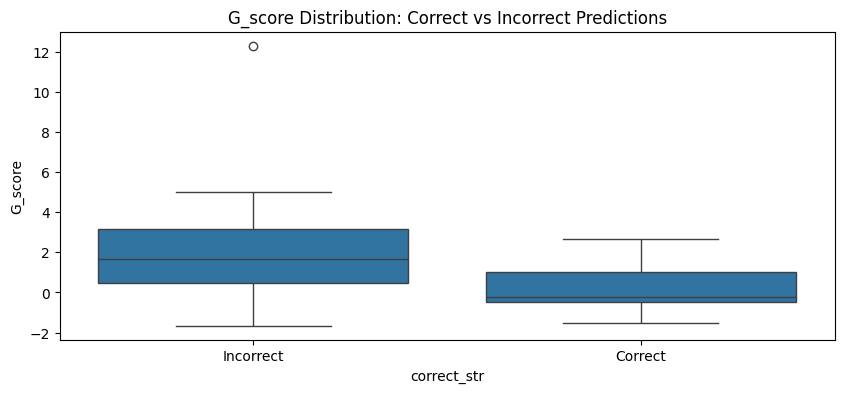

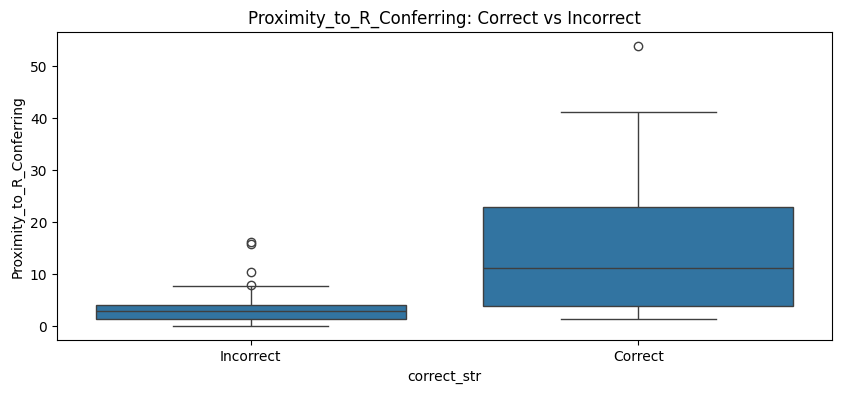

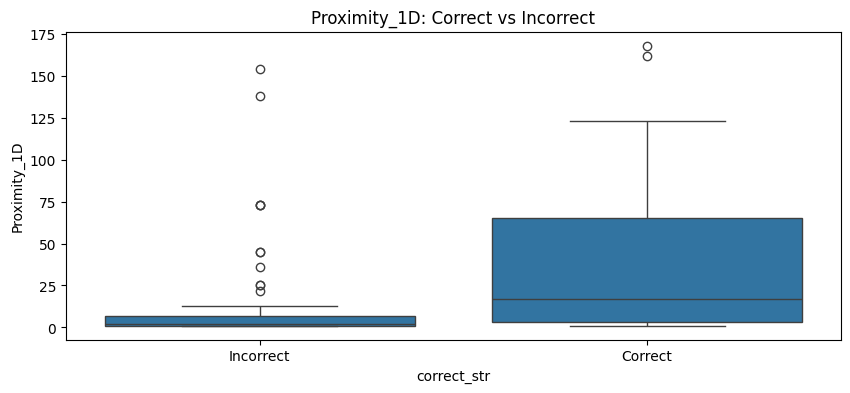

Number of incorrect predictions: 85
       gene one_letter_mutation             confidence_2023  true_label  \
0    Rv0678                L32S                1) Assoc w R           1   
1    Rv0678                A36V      2) Assoc w R - Interim           1   
2    Rv0678                I67S      2) Assoc w R - Interim           1   
3    Rv0678               M146T      2) Assoc w R - Interim           1   
4      embB               S297A                1) Assoc w R           1   
..      ...                 ...                         ...         ...   
98      gid               V124A      2) Assoc w R - Interim           1   
99      gid               V135G                1) Assoc w R           1   
100     gid               A138V                1) Assoc w R           1   
101     gid               L152S      2) Assoc w R - Interim           1   
103    rpsL               G124S  4) Not assoc w R - Interim           0   

     model_prediction  
0                   0  
1              

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


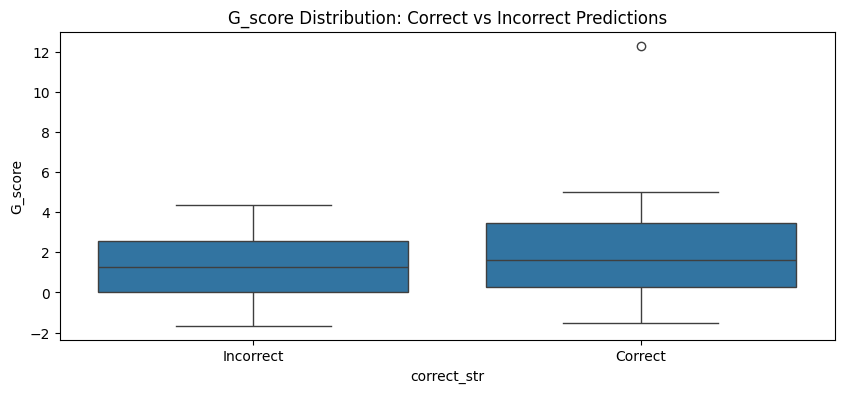

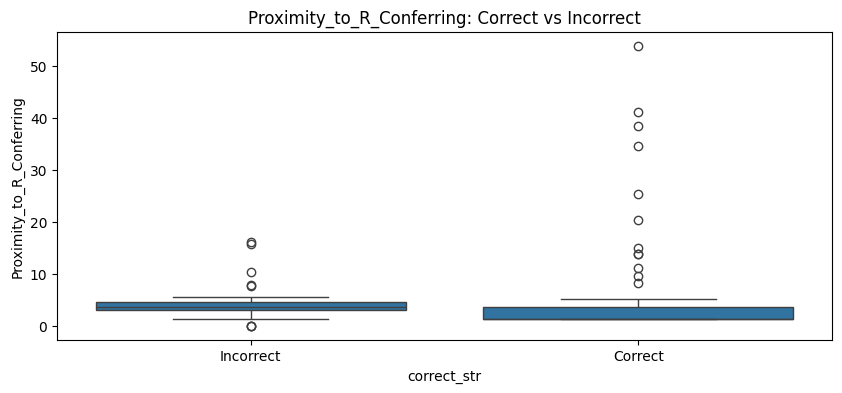

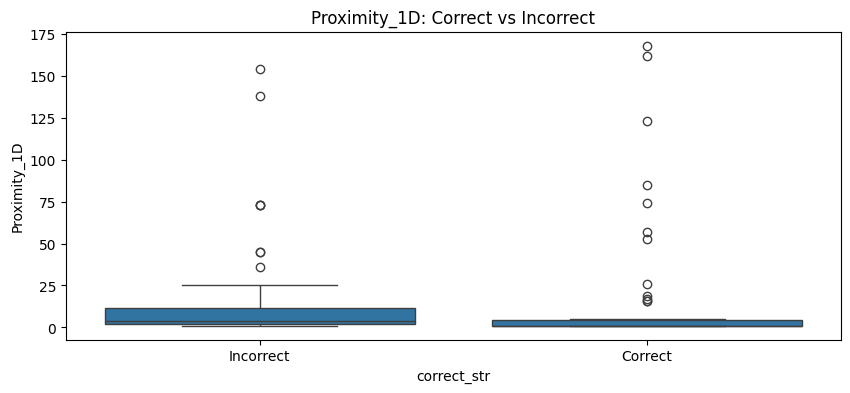

Number of incorrect predictions: 52
       gene one_letter_mutation             confidence_2023  true_label  \
0    Rv0678                L32S                1) Assoc w R           1   
1    Rv0678                A36V      2) Assoc w R - Interim           1   
2    Rv0678                I67S      2) Assoc w R - Interim           1   
3    Rv0678               M146T      2) Assoc w R - Interim           1   
5      embB               S347I                1) Assoc w R           1   
6      embB               S347T                1) Assoc w R           1   
7      embB               L402V                1) Assoc w R           1   
9      embB               V456A                1) Assoc w R           1   
10     embB               T642A      2) Assoc w R - Interim           1   
15     ethA                T61M                1) Assoc w R           1   
16     ethA               L194P      2) Assoc w R - Interim           1   
17     ethA               V202G      2) Assoc w R - Interim     

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


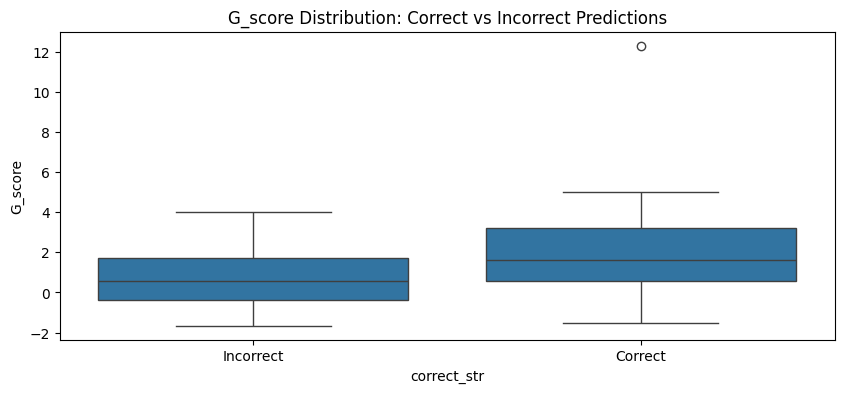

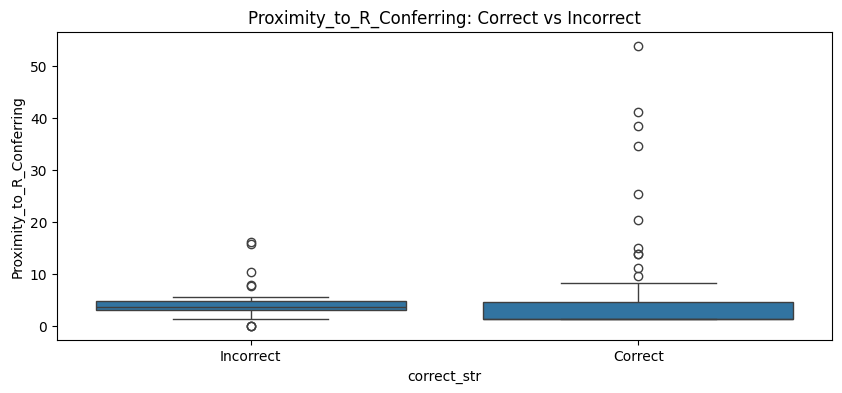

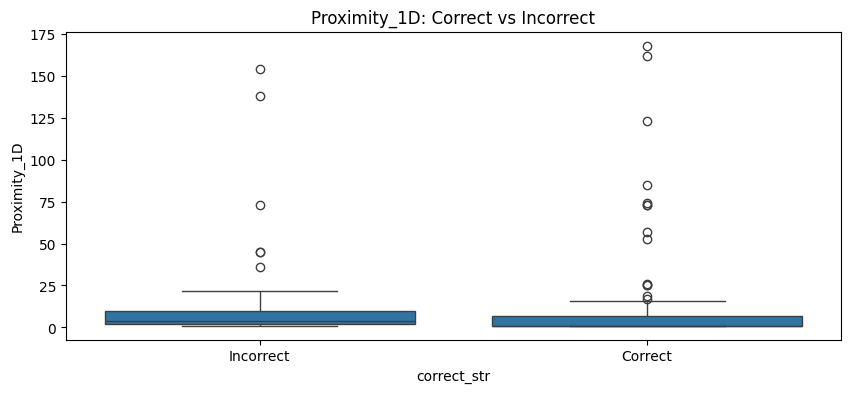

Number of incorrect predictions: 31
       gene one_letter_mutation             confidence_2023  true_label  \
0    Rv0678                L32S                1) Assoc w R           1   
1    Rv0678                A36V      2) Assoc w R - Interim           1   
2    Rv0678                I67S      2) Assoc w R - Interim           1   
3    Rv0678               M146T      2) Assoc w R - Interim           1   
7      embB               L402V                1) Assoc w R           1   
9      embB               V456A                1) Assoc w R           1   
10     embB               T642A      2) Assoc w R - Interim           1   
15     ethA                T61M                1) Assoc w R           1   
16     ethA               L194P      2) Assoc w R - Interim           1   
17     ethA               V202G      2) Assoc w R - Interim           1   
18     ethA               L205P      2) Assoc w R - Interim           1   
22     ethA               T321P                1) Assoc w R     

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


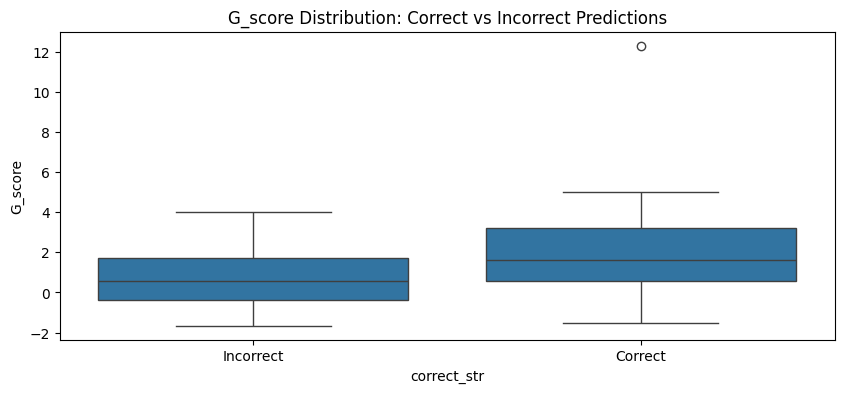

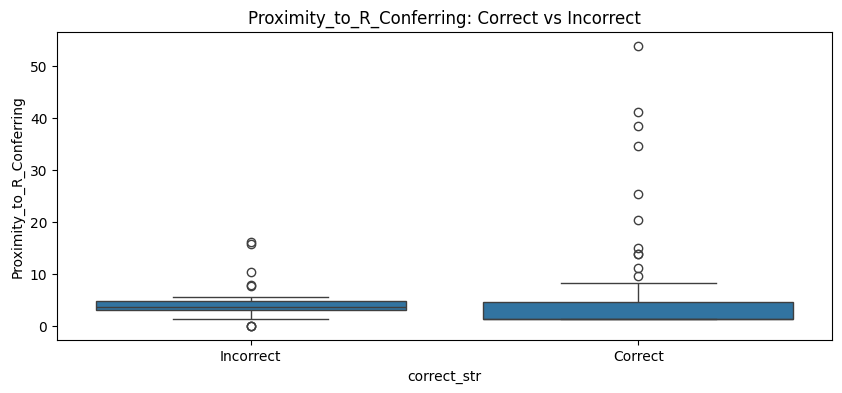

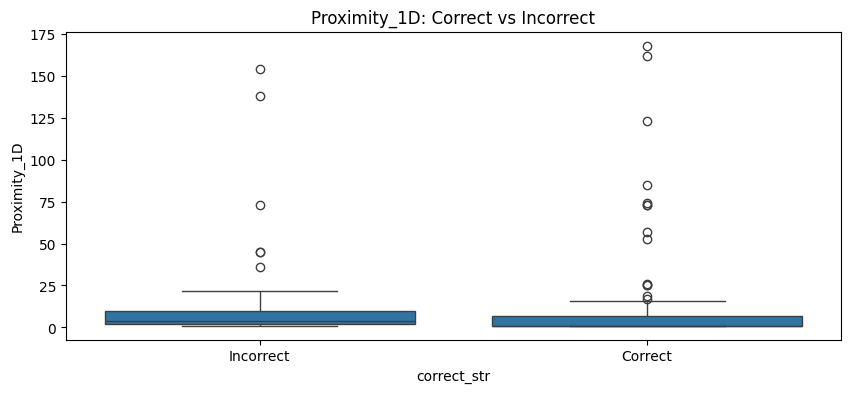

Number of incorrect predictions: 31
       gene one_letter_mutation             confidence_2023  true_label  \
0    Rv0678                L32S                1) Assoc w R           1   
1    Rv0678                A36V      2) Assoc w R - Interim           1   
2    Rv0678                I67S      2) Assoc w R - Interim           1   
3    Rv0678               M146T      2) Assoc w R - Interim           1   
7      embB               L402V                1) Assoc w R           1   
9      embB               V456A                1) Assoc w R           1   
10     embB               T642A      2) Assoc w R - Interim           1   
15     ethA                T61M                1) Assoc w R           1   
16     ethA               L194P      2) Assoc w R - Interim           1   
17     ethA               V202G      2) Assoc w R - Interim           1   
18     ethA               L205P      2) Assoc w R - Interim           1   
22     ethA               T321P                1) Assoc w R     

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


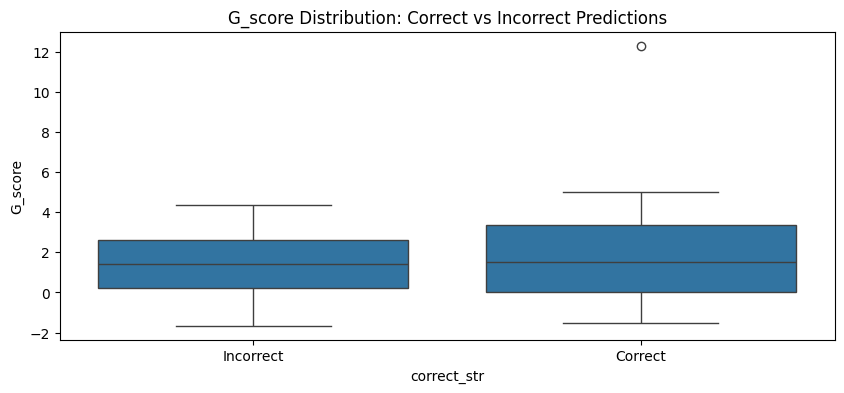

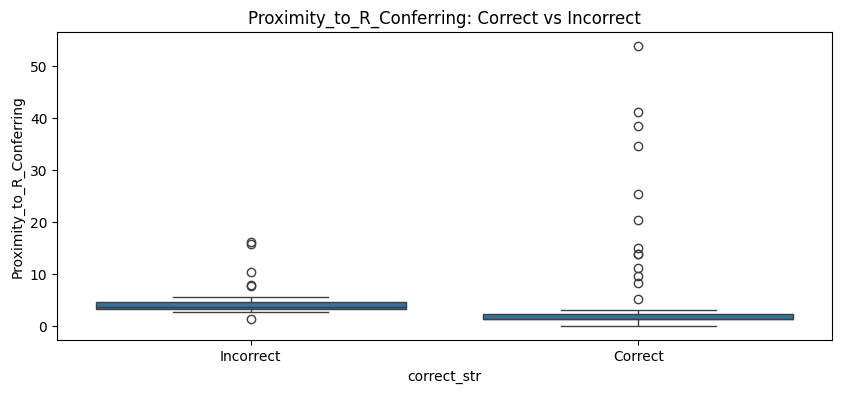

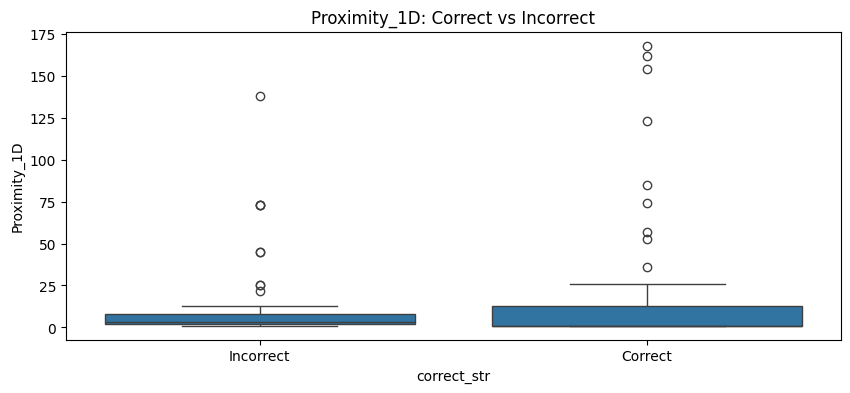

Number of incorrect predictions: 49
       gene one_letter_mutation             confidence_2023  true_label  \
0    Rv0678                L32S                1) Assoc w R           1   
1    Rv0678                A36V      2) Assoc w R - Interim           1   
2    Rv0678                I67S      2) Assoc w R - Interim           1   
3    Rv0678               M146T      2) Assoc w R - Interim           1   
5      embB               S347I                1) Assoc w R           1   
6      embB               S347T                1) Assoc w R           1   
7      embB               L402V                1) Assoc w R           1   
9      embB               V456A                1) Assoc w R           1   
10     embB               T642A      2) Assoc w R - Interim           1   
15     ethA                T61M                1) Assoc w R           1   
16     ethA               L194P      2) Assoc w R - Interim           1   
17     ethA               V202G      2) Assoc w R - Interim     

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


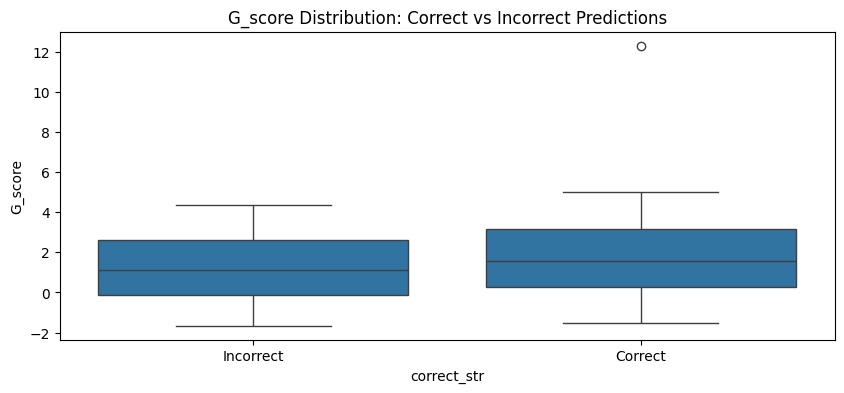

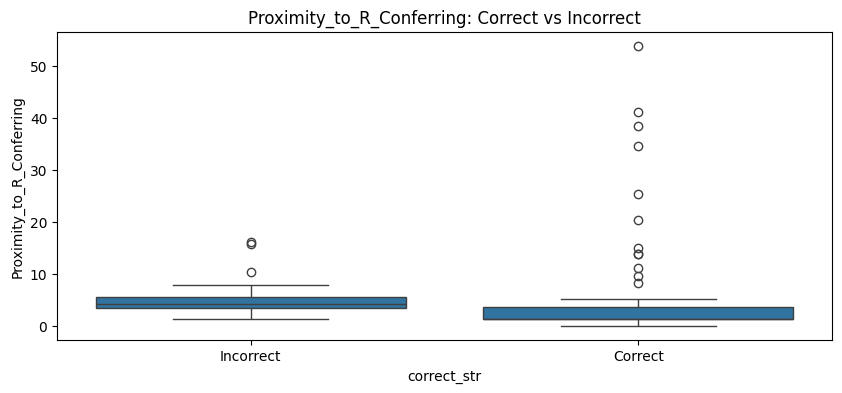

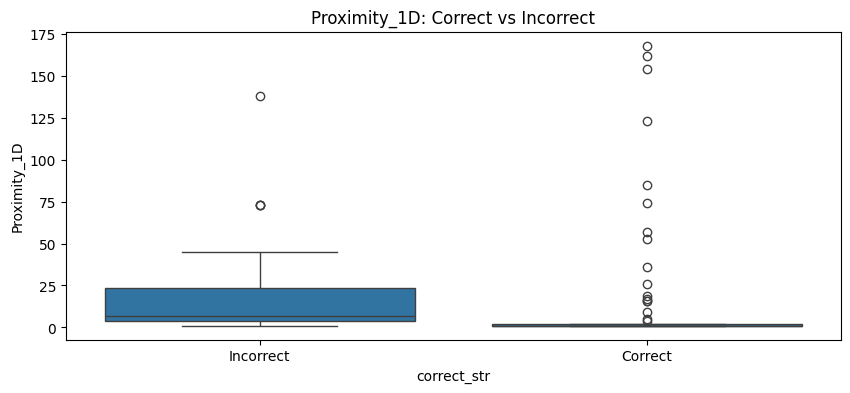

Number of incorrect predictions: 31
       gene one_letter_mutation             confidence_2023  true_label  \
0    Rv0678                L32S                1) Assoc w R           1   
1    Rv0678                A36V      2) Assoc w R - Interim           1   
2    Rv0678                I67S      2) Assoc w R - Interim           1   
3    Rv0678               M146T      2) Assoc w R - Interim           1   
5      embB               S347I                1) Assoc w R           1   
6      embB               S347T                1) Assoc w R           1   
9      embB               V456A                1) Assoc w R           1   
10     embB               T642A      2) Assoc w R - Interim           1   
15     ethA                T61M                1) Assoc w R           1   
16     ethA               L194P      2) Assoc w R - Interim           1   
17     ethA               V202G      2) Assoc w R - Interim           1   
20     ethA               T314I                1) Assoc w R     

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


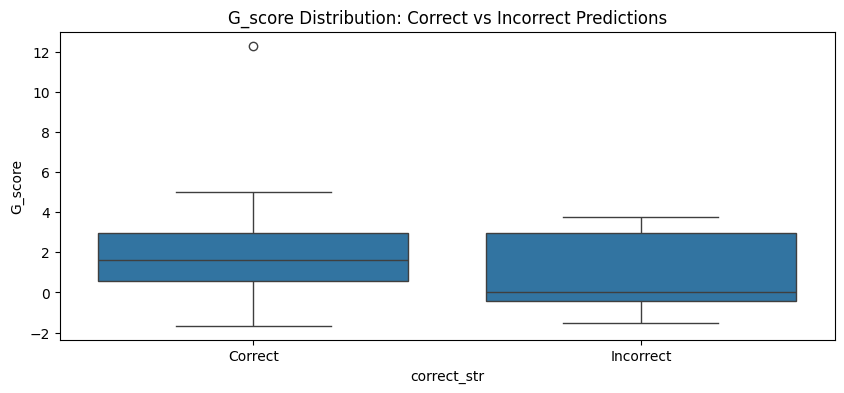

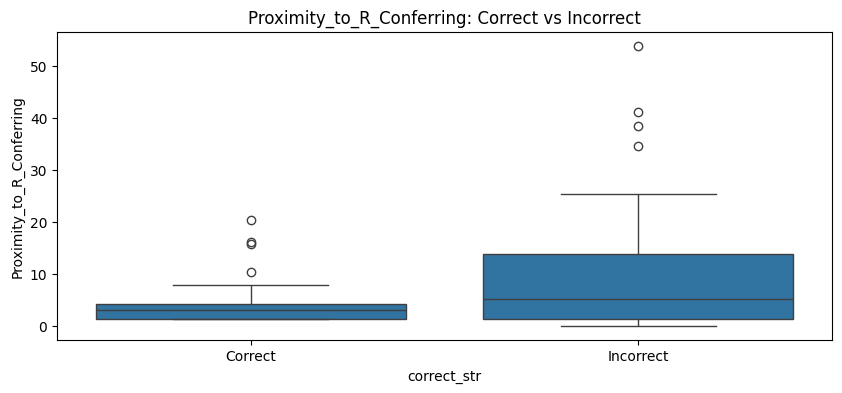

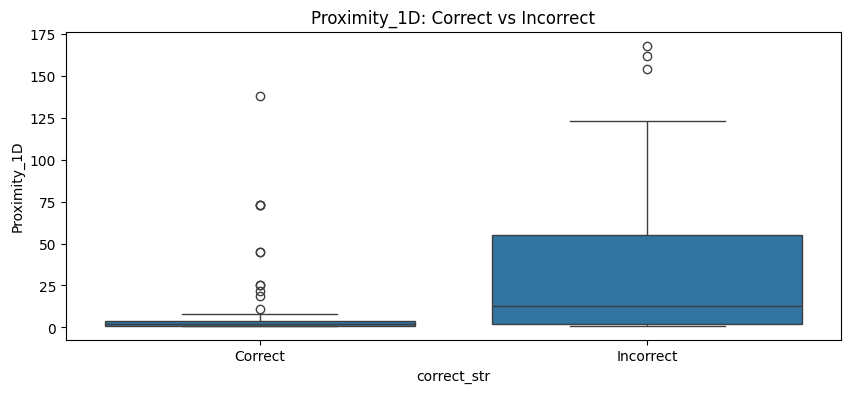

Number of incorrect predictions: 27
       gene one_letter_mutation             confidence_2023  true_label  \
1    Rv0678                A36V      2) Assoc w R - Interim           1   
2    Rv0678                I67S      2) Assoc w R - Interim           1   
8      embB               P404S      2) Assoc w R - Interim           1   
11     embB               V668A  4) Not assoc w R - Interim           0   
14     ethA                S55P      2) Assoc w R - Interim           1   
30     inhA                V78A            5) Not assoc w R           0   
39     katG               S315I                1) Assoc w R           1   
40     katG               S315G                1) Assoc w R           1   
41     katG               T354I  4) Not assoc w R - Interim           0   
42     katG               S457G  4) Not assoc w R - Interim           0   
43     katG               A614T  4) Not assoc w R - Interim           0   
46     gyrA               A456V  4) Not assoc w R - Interim     

/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


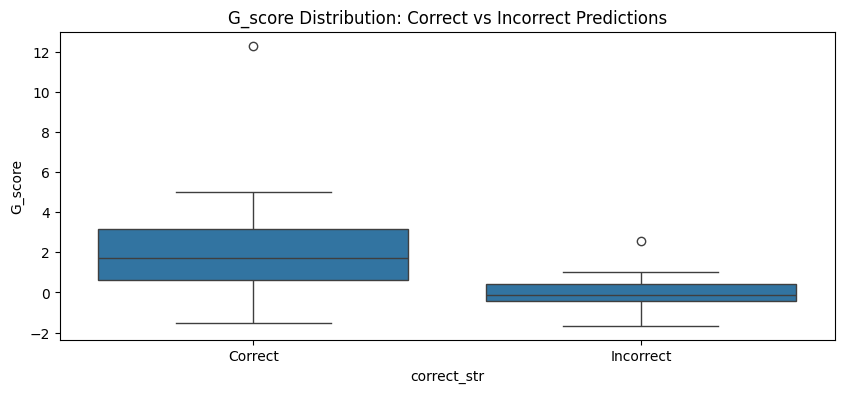

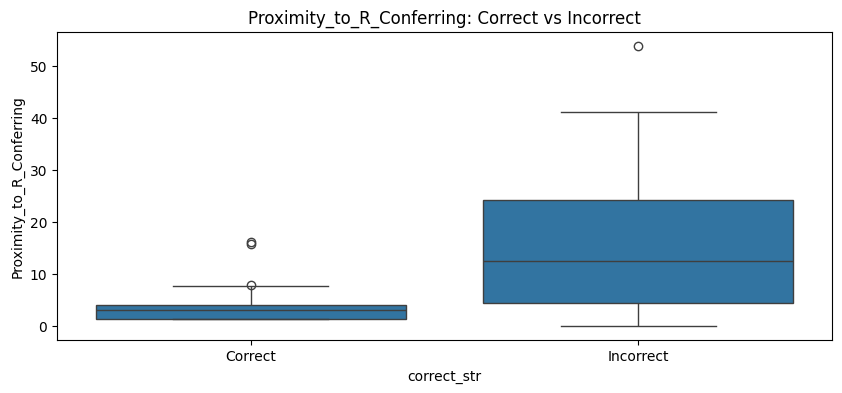

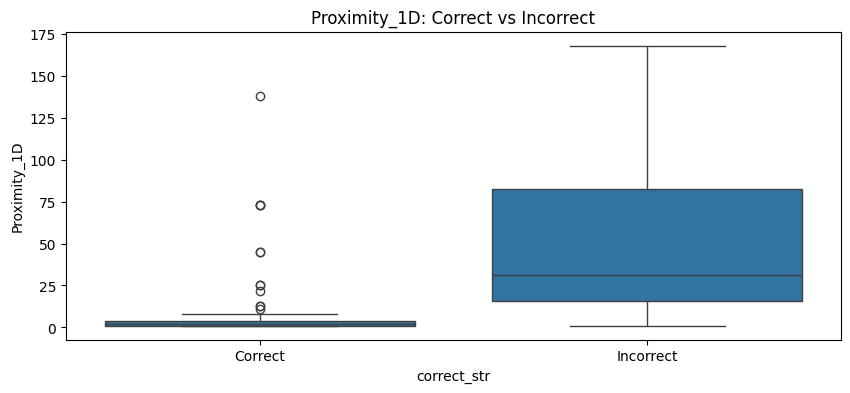

Number of incorrect predictions: 18
     gene one_letter_mutation             confidence_2023  true_label  \
11   embB               V668A  4) Not assoc w R - Interim           0   
22   ethA               T321P                1) Assoc w R           1   
30   inhA                V78A            5) Not assoc w R           0   
41   katG               T354I  4) Not assoc w R - Interim           0   
42   katG               S457G  4) Not assoc w R - Interim           0   
43   katG               A614T  4) Not assoc w R - Interim           0   
44   katG               P718S  4) Not assoc w R - Interim           0   
46   gyrA               A456V  4) Not assoc w R - Interim           0   
47   gyrB               G520A            5) Not assoc w R           0   
48   rplC                A31T            5) Not assoc w R           0   
49   gyrB               T393S  4) Not assoc w R - Interim           0   
73   rpoB                S16C            5) Not assoc w R           0   
74   rpoB      

In [29]:

# Define save directory

# Initialize results list
results_summary = []
for label, numeric_columns in feature_sets.items():
    print(f"\n=== Running model for: {label} ===")

    # Step 1: Feature selection
    label_data[numeric_columns] = label_data[numeric_columns].fillna(0)
    
    # Step 2: Split
    X_train, X_test, y_train, y_test, train_indices, test_indices = data_split(label_data, numeric_columns)
    ## Train RF
    param_path = param_dir / f"rf_best_params_{label}.json"
    with open(param_path) as f:
        best_params = json.load(f)

    # Ensure random_state is reset to int
    best_params["random_state"] = 42
    # Step 4: Predict using trained model
    rf_model = RandomForestClassifier(**best_params)
    rf_model.fit(X_train, y_train)
    y_pred_test = rf_model.predict(X_test)
    y_prob_test = rf_model.predict_proba(X_test)
    evaluate_model(rf_model, "Random Forest", label, numeric_columns, reclassified_eval)

    ## Train logistic Regression
    logreg_model = LogisticRegression(max_iter=1000, random_state=42)
    logreg_model.fit(X_train, y_train)
    evaluate_model(logreg_model, "Logistic Regression", label, numeric_columns, reclassified_eval)
    y_pred_test = logreg_model.predict(X_test)
    y_prob_test = logreg_model.predict_proba(X_test)

results_df = pd.DataFrame(results_summary)

# Reorder columns for clarity
results_df = results_df[
    ['Feature Set', 'Model', 'Accuracy (%)', 'Sensitivity (Res)', 'Specificity (Sus)',
     'Precision (Res)', 'Recall (Res)', 'F1 (Res)',
     'Precision (Sus)', 'Recall (Sus)', 'F1 (Sus)',
     'Support (Res)', 'Support (Sus)', 'Incorrect Predictions']
]

# Display or save
print("\n Summary of Model Performance Across Feature Sets:")
print(results_df.round(2))

# Save to CSV if needed
results_df.to_csv("../data/reclassified_feature_set_summary.csv", index=False)


In [30]:
results_df

,Feature Set,Model,Accuracy (%),Sensitivity (Res),Specificity (Sus),Precision (Res),Recall (Res),F1 (Res),Precision (Sus),Recall (Sus),F1 (Sus),Support (Res),Support (Sus),Incorrect Predictions
0,Proximity,Random Forest,18.269231,4.651163,83.333333,57.142857,4.651163,8.602151,15.463918,83.333333,26.086957,86,18,85
1,Proximity,Logistic Regression,50.000000,44.186047,77.777778,90.476190,44.186047,59.375000,22.580645,77.777778,35.000000,86,18,52
2,Proximity_zeroed,Random Forest,70.192308,68.604651,77.777778,93.650794,68.604651,79.194631,34.146341,77.777778,47.457627,86,18,31
3,Proximity_zeroed,Logistic Regression,70.192308,68.604651,77.777778,93.650794,68.604651,79.194631,34.146341,77.777778,47.457627,86,18,31
4,Proximity_1d,Random Forest,52.884615,44.186047,94.444444,97.435897,44.186047,60.800000,26.153846,94.444444,40.963855,86,18,49
5,Proximity_1d,Logistic Regression,70.192308,65.116279,94.444444,98.245614,65.116279,78.321678,36.170213,94.444444,52.307692,86,18,31
6,G-score,Random Forest,74.038462,88.372093,5.555556,81.720430,88.372093,84.916201,9.090909,5.555556,6.896552,86,18,27
7,G-score,Logistic Regression,82.692308,98.837209,5.555556,83.333333,98.837209,90.425532,50.000000,5.555556,10.000000,86,18,18
